<a href="https://colab.research.google.com/github/Dhanushiya-tech/Portfolio-sample/blob/main/Fashion_MNIST_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision scikit-learn seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

In [3]:
from google.colab import files
uploaded = files.upload()

Saving data.zip to data.zip


In [5]:
import zipfile
import os

zip_file_name = list(uploaded.keys())[0]

# Create a directory to extract files into
extraction_path = "./extracted_data"
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Files extracted to: {extraction_path}")

# List the extracted files (optional)
# for root, dirs, files in os.walk(extraction_path):
#     for name in files:
#         print(os.path.join(root, name))

Files extracted to: ./extracted_data


The `data.zip` file contains images, not a CSV. We need to load these images, preprocess them, and prepare `X` (features) and `y` (labels) for the model. We can infer the labels from the directory names (e.g., 'anastasia' and 'takao').

In [7]:
from PIL import Image
import glob

def load_and_preprocess_images(base_path, image_size=(64, 64)):
    X = []
    y = []
    labels_map = {}
    current_label = 0

    for category_path in glob.glob(os.path.join(base_path, '*')):
        if os.path.isdir(category_path):
            category_name = os.path.basename(category_path)
            if category_name not in labels_map:
                labels_map[category_name] = current_label
                current_label += 1
            label = labels_map[category_name]

            for img_path in glob.glob(os.path.join(category_path, '*.jpg')):
                try:
                    img = Image.open(img_path).convert('L') # Convert to grayscale
                    img = img.resize(image_size) # Resize images
                    img_array = np.array(img).flatten() # Flatten to 1D array
                    X.append(img_array)
                    y.append(label)
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")

    return np.array(X), np.array(y), labels_map

image_size = (64, 64) # Define desired image size
X, y, labels_map = load_and_preprocess_images(extraction_path, image_size)

print(f"Loaded {len(X)} images.")
print(f"Unique labels: {labels_map}")

# Now X and y are defined and can be used by subsequent cells
# Remove the target_column definition as it's not applicable for image data
# And replace the original X and y creation with the new ones

# The next cell (Ik614lw7yuJR) will be modified to use these new X and y
# and remove the df-related code.

Loaded 100 images.
Unique labels: {'takao': 0, 'anastasia': 1}


In [8]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

/tmp/ipykernel_14689/4039078627.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
/tmp/ipykernel_14689/4039078627.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)


In [11]:
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.linear = nn.Linear(input_size, 1)

    def forward(self, x):
        return self.linear(x)   # logits (NO sigmoid here)

model = LogisticRegressionModel(X_train.shape[1])

In [12]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=0.01)

In [13]:
epochs = 100

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.6171
Epoch 10, Loss: 0.0000
Epoch 20, Loss: 0.0000
Epoch 30, Loss: 0.0000
Epoch 40, Loss: 0.0000
Epoch 50, Loss: 0.0000
Epoch 60, Loss: 0.0000
Epoch 70, Loss: 0.0000
Epoch 80, Loss: 0.0000
Epoch 90, Loss: 0.0000


In [14]:
model.eval()

with torch.no_grad():
    outputs = model(X_test)
    predictions = torch.sigmoid(outputs)
    predicted = (predictions > 0.5).float()

accuracy = accuracy_score(y_test, predicted)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.95


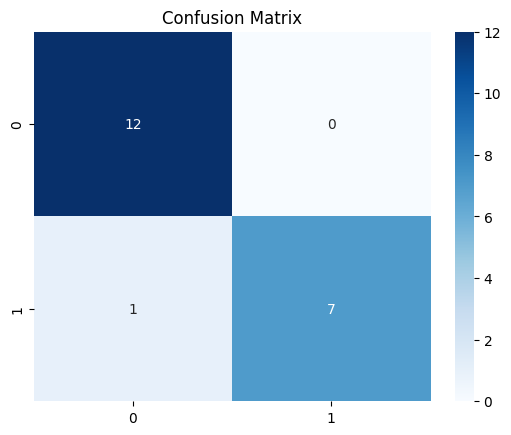

In [15]:
cm = confusion_matrix(y_test, predicted)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

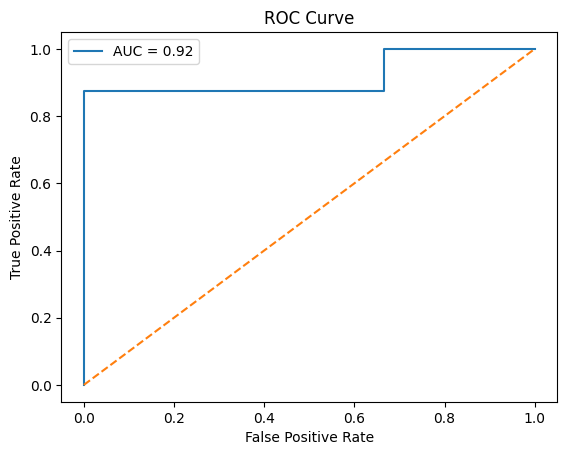

In [16]:
fpr, tpr, _ = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [17]:
torch.save(model.state_dict(), "logistic_model.pth")